# Evidencias preliminares del desarrollo — Clasificador de consultas laborales

**Curso:** Inteligencia Artificial — ULACIT
**Proyecto:** Asistente para clasificar consultas laborales de jóvenes en su primer empleo formal.

En este notebook desarrollamos la parte central de nuestra solución: un **clasificador de texto supervisado**
que recibe una consulta escrita en lenguaje natural y coloquial, y determina a qué **categoría legal** pertenece.
Cuando una consulta corresponde a un caso grave, nuestro sistema la marca para derivarla a un asesor humano en
lugar de responderla de forma automática.

El notebook recorre todo el proceso que seguimos: preparamos los datos, limpiamos el texto, entrenamos el modelo,
medimos su desempeño y probamos el prototipo con consultas nuevas.

Para ejecutarlo, abrimos este archivo en Google Colab y usamos la opción **Ejecutar todo**. No requiere
instalaciones locales ni hardware especializado.

## 1. Instalación de dependencias
Nuestra solución se apoya en dos librerías de código abierto que funcionan en una computadora común: usamos
`spaCy` para el procesamiento del lenguaje y `scikit-learn` para la vectorización y la clasificación. En esta
primera celda las preparamos y, si hace falta, descargamos el modelo de español de spaCy.

In [ ]:
# Instalamos (o confirmamos que estén instaladas) las librerías que utilizamos
!pip install -q spacy scikit-learn pandas matplotlib joblib

# El modelo de español de spaCy es un archivo aparte que trae las reglas del idioma.
# Solo lo descargamos si todavía no está disponible, para no repetir la descarga.
import importlib.util
if importlib.util.find_spec("es_core_news_sm") is None:
    !python -m spacy download es_core_news_sm

print("Dependencias listas.")

Dependencias listas.


In [ ]:
# Importamos las herramientas que vamos a usar a lo largo del cuaderno.

import pandas as pd              # Para organizar los datos en forma de tabla (DataFrame)
import numpy as np               # Para operaciones numéricas
import matplotlib.pyplot as plt  # Para dibujar las gráficas
import spacy                     # Para limpiar y normalizar el texto (procesamiento de lenguaje)
import joblib                    # Para guardar y volver a cargar el modelo entrenado

# Del paquete scikit-learn tomamos las piezas del modelo:
from sklearn.model_selection import train_test_split, cross_val_score   # Dividir datos y validar
from sklearn.feature_extraction.text import TfidfVectorizer             # Convertir texto en números (TF-IDF)
from sklearn.naive_bayes import MultinomialNB                           # Algoritmo Naive Bayes
from sklearn.svm import LinearSVC                                       # Algoritmo SVM (para comparar)
from sklearn.pipeline import Pipeline                                   # Encadenar vectorización + modelo
from sklearn.calibration import CalibratedClassifierCV                  # Calibrar probabilidades
from sklearn.metrics import (classification_report, confusion_matrix,   # Métricas de evaluación
                             ConfusionMatrixDisplay, accuracy_score, f1_score)

# Fijamos una "semilla" para que los resultados sean reproducibles:
# cada vez que corramos el cuaderno obtenemos exactamente la misma división de datos.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


## 2. Construcción del conjunto de datos
Para entrenar el modelo construimos un conjunto de datos con preguntas de ejemplo basadas en las consultas
frecuentes que recibe la organización. Las redactamos en lenguaje coloquial costarricense —con modismos,
abreviaturas y sin tildes— para que se parezcan a como escriben realmente los jóvenes. Cada fila es un par
**`consulta` → `categoria`**.

Ampliamos considerablemente el conjunto original (de 108 a más de 250 ejemplos) agregando variantes coloquiales,
consultas cortas, errores ortográficos y preguntas mixtas para cada categoría. Además incorporamos una categoría
nueva, **`no_relacionado`**, con preguntas totalmente ajenas al ámbito laboral (clima, deportes, cultura general,
saludos, etc.). Esto le enseña al modelo a **reconocer directamente** cuando una consulta no tiene nada que ver
con lo que puede responder, en lugar de depender únicamente del umbral de confianza.

Definimos siete categorías:

| Categoría | Qué agrupa |
|---|---|
| `aguinaldo` | Cálculo, fechas y proporcionalidad del aguinaldo |
| `vacaciones` | Días, acumulación y pago de vacaciones |
| `periodo_prueba` | Duración y derechos durante el periodo de prueba |
| `rebajos_ley` | Deducciones de ley (CCSS, renta, cargas sociales) |
| `jornada_horas_extra` | Jornada máxima, horas extra, feriados y nocturno |
| `escalar_humano` | Casos graves (despido injustificado, acoso, no pago) que derivamos a un asesor |
| `no_relacionado` | Consultas fuera del ámbito laboral (clima, deportes, recetas, saludos, etc.) |

La categoría `escalar_humano` agrupa los casos graves que nuestro sistema no responde de forma automática, sino
que deriva a un asesor. La categoría `no_relacionado` agrupa preguntas que el asistente no debe intentar
responder porque no son consultas laborales. Este conjunto es un punto de partida; más adelante lo ampliaremos
con las consultas históricas reales de la organización.


In [ ]:

# "datos" es una lista de pares (consulta, categoria).
# Cada par le enseña al modelo cómo se ve una consulta de esa categoría.
datos = [
    # ---- aguinaldo ----
    ("cuanto me toca de aguinaldo este año", "aguinaldo"),
    ("cuando pagan el agui", "aguinaldo"),
    ("como se calcula el aguinaldo si entre en agosto", "aguinaldo"),
    ("me van a pagar aguinaldo completo si tengo 4 meses", "aguinaldo"),
    ("el aguinaldo se rebaja o llega completo", "aguinaldo"),
    ("hasta cuando tienen plazo para darme el aguinaldo", "aguinaldo"),
    ("si me salgo antes de diciembre pierdo el aguinaldo?", "aguinaldo"),
    ("como saco el calculo del aguinaldo", "aguinaldo"),
    ("cuanto es el aguinaldo proporcional", "aguinaldo"),
    ("me pagan aguinaldo aunque sea medio tiempo", "aguinaldo"),
    ("el treceavo mes cuando lo dan", "aguinaldo"),
    ("no me pagaron el aguinaldo el año pasado que hago", "aguinaldo"),
    ("cuantos meses necesito para ganar aguinaldo", "aguinaldo"),
    ("el aguinaldo paga impuesto o rebajo", "aguinaldo"),
    ("cuanto seria mi aguinaldo si gano 400 mil", "aguinaldo"),
    ("me corresponde aguinaldo si entre en setiembre", "aguinaldo"),
    ("dan aguinaldo en trabajos por horas", "aguinaldo"),
    ("el aguinaldo entra antes del 20 de diciembre verdad", "aguinaldo"),
    ("cuanto aguinaldo me corresponde por 6 meses trabajados", "aguinaldo"),
    ("el aguinaldo se paga completo o por dias", "aguinaldo"),
    ("si renuncio en noviembre pierdo el aguinaldo", "aguinaldo"),
    ("cuanto seria el aguinaldo con salario minimo", "aguinaldo"),
    ("el aguinaldo aplica para medio tiempo", "aguinaldo"),
    ("cuando cae el pago del aguinaldo este año", "aguinaldo"),
    ("aguinaldo se paga en efectivo o deposito", "aguinaldo"),
    ("que pasa si el patrono no paga el aguinaldo a tiempo", "aguinaldo"),
    ("el aguinaldo cuenta las horas extra", "aguinaldo"),
    ("cuanto de aguinaldo me toca si gano por comision", "aguinaldo"),
    ("aguinaldo pa cuando cae", "aguinaldo"),
    ("agui cuanto es este año", "aguinaldo"),
    ("cae el aguinaldo antes de navidad", "aguinaldo"),
    ("el aguinaldo se calcula con el salario bruto o neto", "aguinaldo"),
    ("tengo dos trabajos me pagan aguinaldo en ambos", "aguinaldo"),
    ("cuanto aguinaldo me toca si entre en enero", "aguinaldo"),
    ("el aguinaldo prescribe si no lo reclamo", "aguinaldo"),
    ("si estoy incapacitada me pagan aguinaldo", "aguinaldo"),
    ("aguinaldo se paga aunque este a prueba", "aguinaldo"),
    ("cuanto aguinaldo llevo acumulado", "aguinaldo"),
    ("el aguinaldo se paga proporcional a las vacaciones", "aguinaldo"),
    ("porque me pagaron menos aguinaldo este año", "aguinaldo"),
    # ---- vacaciones ----
    ("cuantos dias de vacaciones tengo", "vacaciones"),
    ("ya puedo pedir vacaciones", "vacaciones"),
    ("cuanto tiempo debo trabajar para tener vacaciones", "vacaciones"),
    ("me pagan las vacaciones si me voy del trabajo", "vacaciones"),
    ("cuantos dias de vacas me tocan al año", "vacaciones"),
    ("como pido mis vacaciones al patrono", "vacaciones"),
    ("las vacaciones son 15 dias o cuanto", "vacaciones"),
    ("puedo juntar las vacaciones de dos años", "vacaciones"),
    ("me deben vacaciones no disfrutadas", "vacaciones"),
    ("cuantos dias libres me dan por vacaciones", "vacaciones"),
    ("las vacaciones se pagan aparte del salario", "vacaciones"),
    ("cada cuanto tengo derecho a vacaciones", "vacaciones"),
    ("si no tomo vacaciones me las pagan", "vacaciones"),
    ("puedo pedir vacaciones despues de 3 meses", "vacaciones"),
    ("cuantas semanas de vacaciones son por ley", "vacaciones"),
    ("me quede sin disfrutar vacaciones y renuncie", "vacaciones"),
    ("el patrono decide cuando doy vacaciones?", "vacaciones"),
    ("tengo derecho a vacaciones si soy nuevo", "vacaciones"),
    ("cuantos dias de vacaciones tengo despues de dos años", "vacaciones"),
    ("las vacaciones caducan si no las uso", "vacaciones"),
    ("puedo cobrar las vacaciones en vez de tomarlas", "vacaciones"),
    ("cuantos dias de vacaciones me tocan por medio tiempo", "vacaciones"),
    ("el patrono me puede negar las vacaciones", "vacaciones"),
    ("cuanto se acumulan las vacaciones por mes", "vacaciones"),
    ("vacas cuando me tocan", "vacaciones"),
    ("cuantos dias de vacaciones llevo acumulados", "vacaciones"),
    ("puedo dividir mis vacaciones en varias veces", "vacaciones"),
    ("las vacaciones incluyen fines de semana", "vacaciones"),
    ("si trabajo medio tiempo tengo vacaciones proporcionales", "vacaciones"),
    ("cuanto me pagan si no disfrute las vacaciones", "vacaciones"),
    ("las vacaciones se pierden si no las pido", "vacaciones"),
    ("puedo salir de vacaciones antes del año", "vacaciones"),
    ("cuantos dias siguen siendo vacaciones si caen en feriado", "vacaciones"),
    ("vacaciones acumuladas de cuantos años puedo pedir", "vacaciones"),
    ("tengo que avisar con cuanto tiempo para las vacaciones", "vacaciones"),
    ("las vacaciones se pagan con aguinaldo incluido", "vacaciones"),
    ("puedo trabajar durante mis vacaciones", "vacaciones"),
    ("cuanto tiempo tiene el patrono para darme vacaciones", "vacaciones"),
    # ---- periodo_prueba ----
    ("que es el periodo de prueba", "periodo_prueba"),
    ("me pueden botar en el periodo de prueba", "periodo_prueba"),
    ("cuanto dura el periodo de prueba", "periodo_prueba"),
    ("en la prueba me pagan igual", "periodo_prueba"),
    ("si me despiden en prueba me dan liquidacion", "periodo_prueba"),
    ("cuantos meses es el periodo de prueba en cr", "periodo_prueba"),
    ("durante la prueba tengo los mismos derechos", "periodo_prueba"),
    ("me pueden echar sin preaviso en la prueba", "periodo_prueba"),
    ("el periodo de prueba son 3 meses?", "periodo_prueba"),
    ("estoy en prueba y me sacaron es legal", "periodo_prueba"),
    ("en periodo de prueba cotizo a la caja", "periodo_prueba"),
    ("que pasa cuando termina el periodo de prueba", "periodo_prueba"),
    ("me pueden renovar el periodo de prueba", "periodo_prueba"),
    ("en prueba tengo derecho a aguinaldo", "periodo_prueba"),
    ("cuanto tiempo dura la prueba en un trabajo nuevo", "periodo_prueba"),
    ("estoy a prueba me pueden bajar el sueldo", "periodo_prueba"),
    ("la prueba cuenta para la antiguedad", "periodo_prueba"),
    ("si paso la prueba quedo fijo", "periodo_prueba"),
    ("el periodo de prueba aplica en todos los trabajos", "periodo_prueba"),
    ("puedo renunciar durante el periodo de prueba sin problema", "periodo_prueba"),
    ("el periodo de prueba se puede alargar mas de 3 meses", "periodo_prueba"),
    ("en prueba me pueden bajar el salario pactado", "periodo_prueba"),
    ("el periodo de prueba aplica en contratos por tiempo definido", "periodo_prueba"),
    ("si me enfermo en el periodo de prueba que pasa", "periodo_prueba"),
    ("en prueba tengo derecho a incapacidad", "periodo_prueba"),
    ("puedo negociar el periodo de prueba", "periodo_prueba"),
    ("el periodo de prueba cuenta para la cesantia", "periodo_prueba"),
    ("estoy en prueba y quiero renunciar debo avisar", "periodo_prueba"),
    ("en prueba me pueden cambiar de puesto", "periodo_prueba"),
    ("que pasa si no me dicen que estoy en periodo de prueba", "periodo_prueba"),
    ("el periodo de prueba es obligatorio por ley", "periodo_prueba"),
    ("en prueba tengo vacaciones proporcionales", "periodo_prueba"),
    ("prueba de tres meses se puede acortar", "periodo_prueba"),
    ("si quedo fijo despues de la prueba cambia mi contrato", "periodo_prueba"),
    ("en el periodo de prueba pagan horas extra", "periodo_prueba"),
    ("puedo estar a prueba mas de una vez con el mismo patrono", "periodo_prueba"),
    ("la prueba aplica para trabajos temporales", "periodo_prueba"),
    ("en prueba me pueden pedir que trabaje fines de semana", "periodo_prueba"),
    # ---- rebajos_ley ----
    ("por que me rebajan tanto del salario", "rebajos_ley"),
    ("que es lo que me rebajan de la caja", "rebajos_ley"),
    ("cuanto es el rebajo de ley del sueldo", "rebajos_ley"),
    ("por que me quitan plata de la ccss", "rebajos_ley"),
    ("que rebajos son obligatorios por ley", "rebajos_ley"),
    ("me rebajan mucho es normal", "rebajos_ley"),
    ("cuanto porcentaje me quitan del salario", "rebajos_ley"),
    ("que es el seguro social que me rebajan", "rebajos_ley"),
    ("me cobran renta del salario", "rebajos_ley"),
    ("por que mi salario neto es menor al bruto", "rebajos_ley"),
    ("los rebajos de ley cuanto suman", "rebajos_ley"),
    ("me estan rebajando de mas del sueldo", "rebajos_ley"),
    ("que deducciones me hacen del salario", "rebajos_ley"),
    ("el rebajo de la caja es obligatorio", "rebajos_ley"),
    ("cuanto pago de cargas sociales", "rebajos_ley"),
    ("por que me descuentan del pago quincenal", "rebajos_ley"),
    ("el impuesto de renta desde cuanto se cobra", "rebajos_ley"),
    ("que significa el rebajo del 10 por ciento", "rebajos_ley"),
    ("cuanto rebajan por el banco popular", "rebajos_ley"),
    ("el rebajo de la caja es igual para todos los salarios", "rebajos_ley"),
    ("que porcentaje se destina a pensiones en el rebajo", "rebajos_ley"),
    ("los rebajos de ley aplican en medio tiempo", "rebajos_ley"),
    ("cuanto es el rebajo si gano el salario minimo", "rebajos_ley"),
    ("el rebajo de renta desde que monto empieza", "rebajos_ley"),
    ("que cubre el rebajo del seguro social", "rebajos_ley"),
    ("los prestamos se pueden rebajar del salario sin permiso", "rebajos_ley"),
    ("el patrono puede rebajarme por llegar tarde", "rebajos_ley"),
    ("cuanto rebajan de ley en un trabajo por horas", "rebajos_ley"),
    ("el rebajo de ccss lo paga tambien el patrono", "rebajos_ley"),
    ("que pasa si no me hacen los rebajos de ley", "rebajos_ley"),
    ("los rebajos de ley bajan si gano menos", "rebajos_ley"),
    ("cuanto es el total de cargas sociales que pagan entre los dos", "rebajos_ley"),
    ("el rebajo de renta se hace cada mes o cada año", "rebajos_ley"),
    ("puedo pedir que no me rebajen banco popular", "rebajos_ley"),
    ("que es el rebajo obrero patronal", "rebajos_ley"),
    ("los rebajos de ley aplican en aguinaldo", "rebajos_ley"),
    ("cuanto rebajan si trabajo por servicios profesionales", "rebajos_ley"),
    ("el rebajo de la caja me da derecho a algo", "rebajos_ley"),
    # ---- jornada_horas_extra ----
    ("me tienen que pagar las horas extra", "jornada_horas_extra"),
    ("cuantas horas puedo trabajar al dia", "jornada_horas_extra"),
    ("si trabajo domingo me pagan doble", "jornada_horas_extra"),
    ("las horas extra como se pagan", "jornada_horas_extra"),
    ("me hacen trabajar 12 horas es legal", "jornada_horas_extra"),
    ("cuanto es la jornada maxima por ley", "jornada_horas_extra"),
    ("trabajo de noche me pagan mas", "jornada_horas_extra"),
    ("me obligan a quedarme mas horas sin pago", "jornada_horas_extra"),
    ("las horas extra son el doble o cuanto", "jornada_horas_extra"),
    ("cuantas horas extra puedo hacer al dia", "jornada_horas_extra"),
    ("trabajo feriado me pagan aparte", "jornada_horas_extra"),
    ("la jornada nocturna cuantas horas es", "jornada_horas_extra"),
    ("me deben las horas extra de la semana", "jornada_horas_extra"),
    ("cuanto es una hora extra si gano por hora", "jornada_horas_extra"),
    ("puedo negarme a hacer horas extra", "jornada_horas_extra"),
    ("trabajo 6 dias a la semana esta bien", "jornada_horas_extra"),
    ("cuanto descanso me toca entre jornadas", "jornada_horas_extra"),
    ("las horas de mas no me las quieren pagar", "jornada_horas_extra"),
    ("cuantas horas puedo trabajar en jornada mixta", "jornada_horas_extra"),
    ("las horas extra se pagan aunque sea salario fijo", "jornada_horas_extra"),
    ("puedo trabajar los siete dias de la semana", "jornada_horas_extra"),
    ("que pasa si trabajo mas de 12 horas en un dia", "jornada_horas_extra"),
    ("las horas extra se calculan sobre el salario base", "jornada_horas_extra"),
    ("tengo derecho a un dia libre a la semana", "jornada_horas_extra"),
    ("el trabajo en feriado de pago obligatorio es doble o mas", "jornada_horas_extra"),
    ("cuantas horas extra maximas puedo hacer al mes", "jornada_horas_extra"),
    ("si trabajo turno nocturno cuanto es el plus", "jornada_horas_extra"),
    ("me pueden obligar a hacer horas extra siempre", "jornada_horas_extra"),
    ("cuanto descanso debo tener entre un turno y otro", "jornada_horas_extra"),
    ("las horas extra prescriben si no las reclamo", "jornada_horas_extra"),
    ("trabajo por turnos rotativos eso es legal", "jornada_horas_extra"),
    ("cuanto es la jornada maxima semanal permitida", "jornada_horas_extra"),
    ("si trabajo el dia libre me lo deben reponer", "jornada_horas_extra"),
    ("las horas extra se pagan en efectivo o se acumulan", "jornada_horas_extra"),
    ("puedo pedir que me paguen las horas extra en vez de descanso", "jornada_horas_extra"),
    ("cuanto tiempo de almuerzo me corresponde en la jornada", "jornada_horas_extra"),
    ("el trabajo en dia de asueto se paga distinto", "jornada_horas_extra"),
    ("si trabajo horas extra sin autorizacion me las deben pagar", "jornada_horas_extra"),
    # ---- escalar_humano (casos graves) ----
    ("me despidieron sin ninguna razon", "escalar_humano"),
    ("mi jefe me acosa y no se que hacer", "escalar_humano"),
    ("no me quieren pagar la liquidacion", "escalar_humano"),
    ("me tratan muy mal en el trabajo", "escalar_humano"),
    ("me echaron por estar embarazada", "escalar_humano"),
    ("mi patrono me amenaza si reclamo", "escalar_humano"),
    ("me despidieron por incapacidad", "escalar_humano"),
    ("sufro acoso sexual de un compañero", "escalar_humano"),
    ("me botaron y no me pagaron nada", "escalar_humano"),
    ("necesito hablar con un abogado urgente", "escalar_humano"),
    ("me discriminan por mi edad en el trabajo", "escalar_humano"),
    ("mi jefe me grita y me humilla", "escalar_humano"),
    ("me despidieron injustificadamente", "escalar_humano"),
    ("quiero poner una denuncia contra mi patrono", "escalar_humano"),
    ("no me pagan el salario desde hace meses", "escalar_humano"),
    ("me obligan a trabajar enfermo", "escalar_humano"),
    ("me acosan laboralmente todos los dias", "escalar_humano"),
    ("me quieren despedir sin justa causa", "escalar_humano"),
    ("me redujeron el salario sin avisar", "escalar_humano"),
    ("mi jefe me hostiga fuera del horario de trabajo", "escalar_humano"),
    ("me despidieron por reclamar mis derechos", "escalar_humano"),
    ("no me han dado de alta en la ccss", "escalar_humano"),
    ("me obligan a firmar renuncia sin quererlo", "escalar_humano"),
    ("sufro discriminacion por mi orientacion sexual en el trabajo", "escalar_humano"),
    ("mi patrono no respeta mi incapacidad medica", "escalar_humano"),
    ("me amenazan con despedirme si me enfermo", "escalar_humano"),
    ("no me pagan las horas extra desde hace meses", "escalar_humano"),
    ("me despidieron por estar embarazada de nuevo", "escalar_humano"),
    ("mi jefe me toca sin mi consentimiento", "escalar_humano"),
    ("me obligan a trabajar sin las medidas de seguridad", "escalar_humano"),
    ("quiero denunciar a mi patrono por abuso", "escalar_humano"),
    ("me despidieron y no me dieron ninguna explicacion", "escalar_humano"),
    ("sufro violencia laboral necesito ayuda urgente", "escalar_humano"),
    ("mi patrono no me quiere dar la carta de despido", "escalar_humano"),
    ("me deben mas de tres meses de salario", "escalar_humano"),
    ("me discriminan por mi religion en el trabajo", "escalar_humano"),
    ("necesito asesoria legal por un despido injusto", "escalar_humano"),
    ("mi jefe me amenaza con quitarme el trabajo", "escalar_humano"),
    # ---- no_relacionado (fuera del ámbito laboral) ----
    ("cual es la capital de costa rica", "no_relacionado"),
    ("como se hace un gallo pinto", "no_relacionado"),
    ("quien gano el mundial de futbol", "no_relacionado"),
    ("que tiempo va a hacer mañana", "no_relacionado"),
    ("cual es la mejor pelicula del año", "no_relacionado"),
    ("como puedo aprender ingles rapido", "no_relacionado"),
    ("cuantos habitantes tiene costa rica", "no_relacionado"),
    ("recomiendame una serie para ver", "no_relacionado"),
    ("como se prepara un casado tico", "no_relacionado"),
    ("cual es el mejor equipo de futbol", "no_relacionado"),
    ("que hora es en japon", "no_relacionado"),
    ("como bajar de peso rapido", "no_relacionado"),
    ("cual es la capital de francia", "no_relacionado"),
    ("que canciones estan de moda", "no_relacionado"),
    ("como puedo aprender a programar", "no_relacionado"),
    ("cual es el precio del dolar hoy", "no_relacionado"),
    ("donde puedo comer barato cerca", "no_relacionado"),
    ("que playa me recomienda visitar", "no_relacionado"),
    ("como se llama el presidente actual", "no_relacionado"),
    ("cual es el significado de la vida", "no_relacionado"),
    ("que puedo hacer este fin de semana", "no_relacionado"),
    ("como entreno para una maraton", "no_relacionado"),
    ("cual es el mejor celular para comprar", "no_relacionado"),
    ("que pelicula gano el oscar", "no_relacionado"),
    ("como puedo mejorar mi curriculum", "no_relacionado"),
    ("cuentame un chiste", "no_relacionado"),
    ("hola como estas", "no_relacionado"),
    ("buenos dias como amaneciste", "no_relacionado"),
    ("que dia es hoy", "no_relacionado"),
    ("cual es la capital de alemania", "no_relacionado"),
    ("como se dice gracias en ingles", "no_relacionado"),
    ("que recomiendas para el dolor de cabeza", "no_relacionado"),
    ("cual es el animal mas rapido del mundo", "no_relacionado"),
    ("como puedo crear una cuenta de correo", "no_relacionado"),
    ("cuanto cuesta un boleto de avion a españa", "no_relacionado"),
    ("cual es el rio mas largo del mundo", "no_relacionado"),
    ("como se instala una aplicacion en el celular", "no_relacionado"),
    ("que ejercicios puedo hacer en casa", "no_relacionado"),
    ("cual es la historia de costa rica", "no_relacionado"),
    ("como consigo boletos para un concierto", "no_relacionado"),
]

# Convertimos la lista en una tabla (DataFrame) con dos columnas: "consulta" y "categoria".
df = pd.DataFrame(datos, columns=["consulta", "categoria"])

# Guardamos la tabla en un archivo CSV para poder revisarla o ampliarla más adelante.
df.to_csv("dataset_consultas.csv", index=False)

print("Total de ejemplos:", len(df))   # Cuántas consultas tenemos en total
df.head()                              # Mostramos las primeras filas de la tabla


Total de ejemplos: 270


,consulta,categoria
0,cuanto me toca de aguinaldo este año,aguinaldo
1,cuando pagan el agui,aguinaldo
2,como se calcula el aguinaldo si entre en agosto,aguinaldo
3,me van a pagar aguinaldo completo si tengo 4 m...,aguinaldo
4,el aguinaldo se rebaja o llega completo,aguinaldo


In [ ]:
# Ejemplos de intención explícita para evitar confusiones entre temas cercanos.
ejemplos_intencion = [
    ("empece a trabajar en abril para diciembre cuantos dias de vacaciones me corresponden", "vacaciones"),
    ("si entre en abril cuantos dias de vacaciones tengo en diciembre", "vacaciones"),
    ("empece en abril y quiero saber mis dias de vacaciones", "vacaciones"),
    ("para diciembre ya tengo vacaciones si entre en abril", "vacaciones"),
    ("cuantas vacaciones me tocan por llevar meses trabajando", "vacaciones"),
    ("si llevo ocho meses trabajando cuantos dias de vacaciones tengo", "vacaciones"),
    ("cuantos dias de vacaciones corresponden antes de cumplir un año", "vacaciones"),
    ("cuantos dias libres tengo por ley si llevo seis meses", "vacaciones"),
    ("si empece en mayo para diciembre puedo pedir vacaciones", "vacaciones"),
    ("entre en enero cuantas vacaciones tengo acumuladas", "vacaciones"),
    ("la fecha de ingreso cambia mis dias de vacaciones", "vacaciones"),
    ("cuantos dias acumulo de vacaciones por cada mes", "vacaciones"),
    ("si llevo ocho meses ya puedo tomar vacaciones", "vacaciones"),
    ("cuantas vacaciones me tocan si empece en abril", "vacaciones"),
    ("para diciembre cuantos dias libres por vacaciones me corresponden", "vacaciones"),
    ("si trabajo 4 horas extra y gano 2000 por hora cuanto me deben pagar", "jornada_horas_extra"),
    ("cuanto vale una hora extra si gano 300000 al mes", "jornada_horas_extra"),
    ("el 50 por ciento adicional de una hora de 2500 cuanto es", "jornada_horas_extra"),
    ("cuanto me rebajan si gano 450000 y la cuota es 10.67 por ciento", "rebajos_ley"),
    ("que porcentaje representa un rebajo de 45000 sobre 400000", "rebajos_ley"),
    ("si gano 400000 cuanto recibo despues del rebajo de ley", "rebajos_ley"),
    ("empece en septiembre cuanto aguinaldo me toca", "aguinaldo"),
    ("si gano 400000 y entre en septiembre cuanto seria mi aguinaldo", "aguinaldo"),
    ("cuanto es el aguinaldo si trabaje tres meses", "aguinaldo"),
    ("me pagan aguinaldo si solo llevo cuatro meses", "aguinaldo"),
    ("hola necesito ayuda con mi aguinaldo", "aguinaldo"),
    ("hola necesito ayuda con mis vacaciones", "vacaciones"),
    ("mae cuantos dias de vacas me tocan", "vacaciones"),
    ("tengo una pregunta sobre mis vacaciones", "vacaciones"),
    ("me pueden despedir mientras estoy en periodo de prueba", "periodo_prueba"),
    ("cuanto dura la prueba en un trabajo nuevo", "periodo_prueba"),
    ("durante la prueba tengo derecho a vacaciones", "periodo_prueba"),
    ("me despidieron sin pagarme la liquidacion que hago", "escalar_humano"),
    ("mi jefe me acosa y necesito ayuda", "escalar_humano"),
    ("no me pagan desde hace dos meses", "escalar_humano"),
    ("cual es la capital de costa rica", "no_relacionado"),
    ("como preparo gallo pinto", "no_relacionado"),
    ("que pelicula me recomienda", "no_relacionado"),
]
df = pd.concat([df, pd.DataFrame(ejemplos_intencion, columns=["consulta", "categoria"])], ignore_index=True)
df.to_csv("dataset_consultas.csv", index=False)
print("Ejemplos de intención agregados:", len(ejemplos_intencion))
print("Total actualizado:", len(df))


Ejemplos de intención agregados: 38
Total actualizado: 308


### 2.1 Distribución de las categorías
Revisamos cuántos ejemplos tenemos por categoría. Mantuvimos el conjunto **balanceado** (18 consultas por
categoría) para que el modelo no se incline hacia una clase solo por tener más ejemplos que las demás.

categoria
aguinaldo              45
escalar_humano         41
jornada_horas_extra    41
no_relacionado         43
periodo_prueba         41
rebajos_ley            41
vacaciones             56
Name: count, dtype: int64


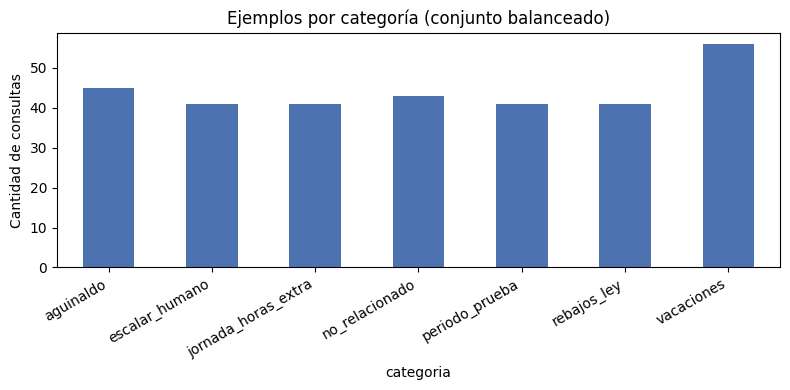

In [ ]:
# value_counts() cuenta cuántas consultas hay en cada categoría.
conteo = df["categoria"].value_counts().sort_index()
print(conteo)

# Dibujamos esas cantidades como un gráfico de barras.
plt.figure(figsize=(8, 4))                        # Tamaño de la figura
conteo.plot(kind="bar", color="#4C72B0")          # Tipo de gráfico y color
plt.title("Ejemplos por categoría (conjunto balanceado)")
plt.ylabel("Cantidad de consultas")
plt.xticks(rotation=30, ha="right")               # Inclinamos las etiquetas para que se lean
plt.tight_layout()                                # Ajusta los márgenes
plt.show()                                         # Muestra el gráfico

## 3. Limpieza del texto con spaCy
Antes de clasificar, limpiamos y normalizamos cada consulta con spaCy. En este paso pasamos el texto a
minúsculas, lo separamos en palabras (**tokenización**), eliminamos las palabras vacías o *stopwords* (como
"de", "el", "que") y los signos de puntuación, y llevamos cada palabra a su forma base (**lematización**):
por ejemplo, *"vacaciones"* se convierte en *"vacación"* y *"pagan"* en *"pagar"*. Con esto reducimos el ruido
y logramos que consultas escritas de distintas formas queden representadas de manera parecida.

In [ ]:
import re

# Cargamos el modelo de español. Desactivamos los componentes que no necesitamos
# (reconocimiento de entidades y análisis sintáctico) para que sea más rápido.
nlp = spacy.load("es_core_news_sm", disable=["ner", "parser"])

REEMPLAZOS_TEXTO = {
    "agui": "aguinaldo",
    "aguinald": "aguinaldo",
    "vacas": "vacaciones",
    "vacacione": "vacaciones",
    "pruba": "prueba",
    "ccss": "caja seguro social",
    "patrono": "empleador",
    "jefe": "empleador",
    "botaron": "despidieron",
    "echaron": "despidieron",
    "rebajan": "descuentan",
    "rebajo": "descuento",
}


def normalizar_consulta(texto):
    texto_normalizado = str(texto).lower()
    for origen, destino in REEMPLAZOS_TEXTO.items():
        texto_normalizado = re.sub(rf"\b{re.escape(origen)}\b", destino, texto_normalizado)
    return texto_normalizado


def limpiar_texto(texto):
    """Recibe una consulta cruda y devuelve el texto limpio y normalizado."""
    doc = nlp(normalizar_consulta(texto))
    tokens = [
        t.lemma_
        for t in doc
        if not t.is_stop
        and not t.is_punct
        and not t.is_space
        and len(t.lemma_) > 1
    ]
    return " ".join(tokens)


# Aplicamos la misma limpieza a los datos de entrenamiento y a las consultas nuevas.
df["consulta_limpia"] = df["consulta"].apply(limpiar_texto)
df[["consulta", "consulta_limpia"]].head(6)


,consulta,consulta_limpia
0,cuanto me toca de aguinaldo este año,tocar aguinaldo año
1,cuando pagan el agui,pagar aguinaldo
2,como se calcula el aguinaldo si entre en agosto,calcular aguinaldo agosto
3,me van a pagar aguinaldo completo si tengo 4 m...,pagar aguinaldo completo mes
4,el aguinaldo se rebaja o llega completo,aguinaldo rebajar llegar completo
5,hasta cuando tienen plazo para darme el aguinaldo,plazo dar yo aguinaldo


In [ ]:
import re

# Normalizamos expresiones frecuentes antes de vectorizar para reducir ruido ortográfico y coloquial.
REEMPLAZOS_TEXTO = {
    "agui": "aguinaldo",
    "aguinald": "aguinaldo",
    "vacas": "vacaciones",
    "vacacione": "vacaciones",
    "pruba": "prueba",
    "ccss": "caja seguro social",
    "patrono": "empleador",
    "jefe": "empleador",
    "botaron": "despidieron",
    "echaron": "despidieron",
    "rebajan": "descuentan",
    "rebajo": "descuento",
}


def normalizar_consulta(texto):
    texto_normalizado = str(texto).lower()
    for origen, destino in REEMPLAZOS_TEXTO.items():
        texto_normalizado = re.sub(rf"\b{re.escape(origen)}\b", destino, texto_normalizado)
    return texto_normalizado


df["consulta_limpia"] = df["consulta"].apply(normalizar_consulta).apply(limpiar_texto)
df[["consulta", "consulta_limpia"]].head(6)


,consulta,consulta_limpia
0,cuanto me toca de aguinaldo este año,tocar aguinaldo año
1,cuando pagan el agui,pagar aguinaldo
2,como se calcula el aguinaldo si entre en agosto,calcular aguinaldo agosto
3,me van a pagar aguinaldo completo si tengo 4 m...,pagar aguinaldo completo mes
4,el aguinaldo se rebaja o llega completo,aguinaldo rebajar llegar completo
5,hasta cuando tienen plazo para darme el aguinaldo,plazo dar yo aguinaldo


## 4. Vectorización con TF-IDF
Como los algoritmos trabajan con números y no con texto, convertimos cada consulta en un **vector numérico**
usando TF-IDF. Esta técnica asigna a cada palabra un peso según su importancia: una palabra recibe un peso alto
cuando es frecuente en una consulta pero poco común en el resto, ya que resulta más distintiva. Usamos unigramas
y bigramas (`ngram_range=(1, 2)`) para capturar también expresiones de dos palabras, como *"horas extra"* o
*"periodo prueba"*. Integramos la vectorización dentro de un `Pipeline` junto con el clasificador, de modo que
el mismo procesamiento se aplique tanto al entrenar como al predecir.

## 5. División de los datos
Separamos los datos en dos conjuntos: **75% para entrenamiento** y **25% para prueba**. El conjunto de prueba
no se usa durante el entrenamiento; lo reservamos para medir cómo responde el modelo ante consultas que no vio
antes. Usamos `stratify` para conservar la misma proporción de categorías en ambos conjuntos.

In [ ]:
# X son las consultas ya limpias (lo que "entra" al modelo).
# y son las categorías correctas (lo que queremos que el modelo aprenda a predecir).
X = df["consulta_limpia"]
y = df["categoria"]

# Dividimos en entrenamiento (75%) y prueba (25%).
#   test_size=0.25  -> reserva el 25% para probar
#   random_state    -> hace la división reproducible
#   stratify=y      -> mantiene la misma proporción de categorías en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f"Entrenamiento: {len(X_train)} consultas")
print(f"Prueba:        {len(X_test)} consultas")

Entrenamiento: 231 consultas
Prueba:        77 consultas


## 6. Entrenamiento del modelo (Naive Bayes)
Entrenamos un modelo **Multinomial Naive Bayes**, un algoritmo probabilístico, rápido y liviano que funciona
bien en la clasificación de texto. Durante el entrenamiento, el modelo aprende qué palabras se asocian con cada
categoría a partir de los ejemplos.

In [ ]:
# Creamos un Pipeline, que encadena dos pasos en orden:
#   1) tfidf -> convierte el texto en números (vectorización TF-IDF)
#   2) clf   -> el clasificador Naive Bayes que hace la predicción
modelo_nb = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),  # unigramas y bigramas
    ("clf", MultinomialNB())                          # algoritmo Naive Bayes
])

# Entrenamos el modelo con las consultas de entrenamiento y sus categorías.
modelo_nb.fit(X_train, y_train)

# Pedimos al modelo que prediga las categorías del conjunto de prueba.
pred_nb = modelo_nb.predict(X_test)

# Calculamos dos métricas generales:
acc_nb = accuracy_score(y_test, pred_nb)               # % de aciertos totales
f1_nb = f1_score(y_test, pred_nb, average="macro")     # F1 promedio entre categorías
print(f"Accuracy (Naive Bayes): {acc_nb:.3f}")
print(f"F1-score macro:         {f1_nb:.3f}")

Accuracy (Naive Bayes): 0.818
F1-score macro:         0.826


## 7. Evaluación del desempeño
Evaluamos el modelo con el conjunto de prueba y obtenemos tres métricas por categoría: la **precisión** (de lo
que el modelo clasificó en una categoría, cuánto acertó), la **exhaustividad** o *recall* (de todo lo que
realmente pertenecía a esa categoría, cuánto detectó) y el **F1-score** (un balance entre las dos anteriores).

In [ ]:
# El reporte muestra precisión, recall y F1 para cada categoría por separado.
print(classification_report(y_test, pred_nb, zero_division=0))

                     precision    recall  f1-score   support

          aguinaldo       0.77      0.91      0.83        11
     escalar_humano       1.00      0.80      0.89        10
jornada_horas_extra       1.00      0.80      0.89        10
     no_relacionado       1.00      0.45      0.62        11
     periodo_prueba       0.92      1.00      0.96        11
        rebajos_ley       1.00      0.80      0.89        10
         vacaciones       0.57      0.93      0.70        14

           accuracy                           0.82        77
          macro avg       0.89      0.81      0.83        77
       weighted avg       0.88      0.82      0.82        77



### 7.1 Matriz de confusión
La matriz de confusión nos muestra en qué categorías acierta el modelo y con cuáles se confunde. Los valores de
la **diagonal** son los aciertos; los que quedan fuera indican confusiones entre categorías.

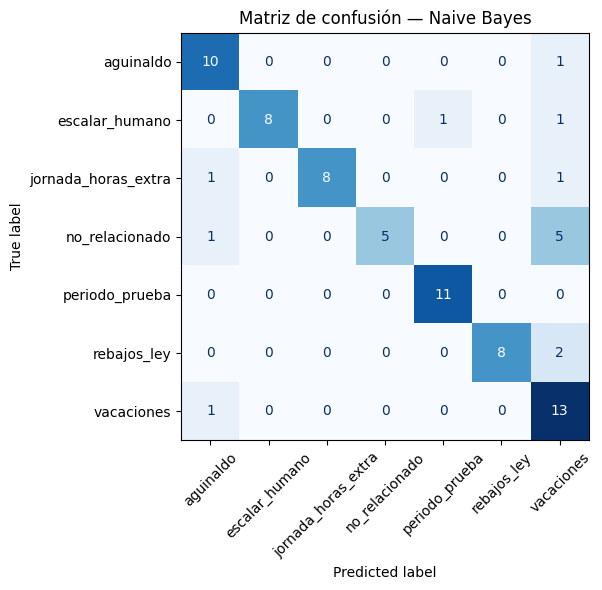

In [ ]:
# Dibujamos la matriz de confusión a partir de las predicciones del modelo.
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_nb,             # valores reales vs. valores predichos
    ax=ax, cmap="Blues",         # eje y mapa de color
    xticks_rotation=45, colorbar=False
)
ax.set_title("Matriz de confusión — Naive Bayes")
plt.tight_layout()
plt.show()

## 8. Comparación con SVM y validación cruzada
Para respaldar nuestra elección, comparamos Naive Bayes con una **Máquina de Vectores de Soporte** (`LinearSVC`).
Además aplicamos **validación cruzada de cinco particiones**, que evalúa el modelo cinco veces sobre distintas
divisiones de los datos y promedia el resultado, de modo que la medición no dependa de una sola división.

In [ ]:
# Construimos un segundo modelo, igual que el anterior, pero con SVM en lugar de Naive Bayes.
modelo_svm = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("clf", LinearSVC())
])
modelo_svm.fit(X_train, y_train)          # Lo entrenamos
pred_svm = modelo_svm.predict(X_test)     # Predecimos sobre el conjunto de prueba

# Comparamos las métricas de ambos modelos.
acc_svm = accuracy_score(y_test, pred_svm)
f1_svm = f1_score(y_test, pred_svm, average="macro")
print(f"Naive Bayes -> accuracy: {acc_nb:.3f} | F1 macro: {f1_nb:.3f}")
print(f"SVM         -> accuracy: {acc_svm:.3f} | F1 macro: {f1_svm:.3f}")

# Validación cruzada de 5 particiones sobre todo el conjunto de datos.
# cross_val_score entrena y prueba 5 veces y devuelve el puntaje de cada vez.
cv_nb = cross_val_score(modelo_nb, X, y, cv=5)
cv_svm = cross_val_score(modelo_svm, X, y, cv=5)
print(f"\nCV Naive Bayes (5 particiones): {cv_nb.round(2)}  media = {cv_nb.mean():.3f}")
print(f"CV SVM         (5 particiones): {cv_svm.round(2)}  media = {cv_svm.mean():.3f}")

Naive Bayes -> accuracy: 0.818 | F1 macro: 0.826
SVM         -> accuracy: 0.922 | F1 macro: 0.920

CV Naive Bayes (5 particiones): [0.9  0.85 0.81 0.79 0.85]  media = 0.841
CV SVM         (5 particiones): [0.95 0.95 0.92 0.92 0.95]  media = 0.938


## 8.1 Optimización con Grid Search
Usamos **Grid Search con validación cruzada** para encontrar la mejor combinación de hiperparámetros del modelo. Exploramos distintos rangos de n-gramas, frecuencia mínima de palabras y el parámetro de suavizado `alpha` de Naive Bayes. Esto garantiza que la configuración seleccionada no sea arbitraria, sino la que maximiza el F1-score en distintas divisiones de los datos.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definimos la cuadrícula de hiperparámetros a explorar
param_grid_nb = {
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],   # unigramas, bigramas, trigramas
    'tfidf__min_df':      [1, 2],                       # frecuencia mínima de palabra
    'clf__alpha':         [0.1, 0.5, 1.0, 2.0]          # suavizado Naive Bayes
}

pipeline_base = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   MultinomialNB())
])

# GridSearchCV evalúa cada combinación con CV=5 y selecciona la que maximiza F1 macro
gs_nb = GridSearchCV(pipeline_base, param_grid_nb,
                     cv=5, scoring='f1_macro', n_jobs=-1, verbose=0)
gs_nb.fit(X_train, y_train)

print("=== Naive Bayes — Grid Search (5-fold CV) ===")
print(f"Mejores parámetros  : {gs_nb.best_params_}")
print(f"Mejor F1 macro (CV) : {gs_nb.best_score_:.3f}")

# Evaluamos el modelo optimizado sobre el conjunto de prueba
modelo_optimizado = gs_nb.best_estimator_
pred_opt = modelo_optimizado.predict(X_test)
acc_opt  = accuracy_score(y_test, pred_opt)
f1_opt   = f1_score(y_test, pred_opt, average='macro')

print("\n--- Comparación final en conjunto de prueba ---")
print(f"Naive Bayes original   -> accuracy: {acc_nb:.3f} | F1 macro: {f1_nb:.3f}")
print(f"Naive Bayes optimizado -> accuracy: {acc_opt:.3f} | F1 macro: {f1_opt:.3f}")
print(f"SVM original           -> accuracy: {acc_svm:.3f} | F1 macro: {f1_svm:.3f}")
print(f"\n✔ Modelo seleccionado para producción: Naive Bayes optimizado")
print(f"  (se elige NB porque provee probabilidades de confianza nativas)")


=== Naive Bayes — Grid Search (5-fold CV) ===
Mejores parámetros  : {'clf__alpha': 1.0, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Mejor F1 macro (CV) : 0.785

--- Comparación final en conjunto de prueba ---
Naive Bayes original   -> accuracy: 0.818 | F1 macro: 0.826
Naive Bayes optimizado -> accuracy: 0.818 | F1 macro: 0.826
SVM original           -> accuracy: 0.922 | F1 macro: 0.920

✔ Modelo seleccionado para producción: Naive Bayes optimizado
  (se elige NB porque provee probabilidades de confianza nativas)


In [ ]:
# Calibramos las probabilidades del modelo seleccionado para que la confianza
# sea más interpretable y no dependa únicamente de la distribución cruda de NB.
modelo_optimizado_base = modelo_optimizado
modelo_optimizado = CalibratedClassifierCV(
    modelo_optimizado_base,
    method="sigmoid",
    cv=5,
)
modelo_optimizado.fit(X_train, y_train)

pred_calibrado = modelo_optimizado.predict(X_test)
acc_calibrado = accuracy_score(y_test, pred_calibrado)
f1_calibrado = f1_score(y_test, pred_calibrado, average="macro")

print("\n--- Modelo calibrado para producción ---")
print(f"Accuracy: {acc_calibrado:.3f} | F1 macro: {f1_calibrado:.3f}")
print("Las probabilidades mostradas desde ahora corresponden al modelo calibrado.")



--- Modelo calibrado para producción ---
Accuracy: 0.857 | F1 macro: 0.859
Las probabilidades mostradas desde ahora corresponden al modelo calibrado.


## 9. Prototipo funcional con umbral de confianza
Esta función integra toda la solución en un solo flujo: recibe una consulta tal como la escribiría un usuario, la limpia, la clasifica y decide la acción. Incorporamos dos criterios de derivación a asesor humano:

1. **Categoría grave** (`escalar_humano`): el modelo detectó un caso que requiere atención especializada.
2. **Confianza insuficiente**: aunque la categoría sea básica, si la probabilidad de la predicción es menor al umbral definido (`UMBRAL_CONFIANZA`), el sistema deriva la consulta en lugar de arriesgarse a dar una respuesta incorrecta.

Las respuestas automáticas se basan en el Código de Trabajo de Costa Rica y los lineamientos del Ministerio de Trabajo y Seguridad Social.

In [ ]:

# ── Umbral de confianza ──────────────────────────────────────────────────────
# Si la probabilidad máxima del modelo es menor a este valor, la consulta se
# deriva a un asesor aunque la categoría predicha no sea escalar_humano.
UMBRAL_CONFIANZA = 0.50

# ── Respuestas basadas en el Código de Trabajo de Costa Rica ─────────────────
RESPUESTAS = {
    "aguinaldo": (
        "Según el Código de Trabajo (Art. 166-168), el aguinaldo equivale a la doceava "
        "parte del salario total devengado entre el 1° de diciembre del año anterior y "
        "el 30 de noviembre del año en curso. Se paga en los primeros 20 días de diciembre. "
        "Si tiene menos de un año de laborar, recibe el proporcional al tiempo trabajado. "
        "Aplica para jornadas completas y parciales, incluidos trabajos por horas."
    ),
    "vacaciones": (
        "El Código de Trabajo (Art. 153-162) establece 2 semanas de vacaciones por cada "
        "50 semanas trabajadas en forma continua. Si termina la relación antes de cumplir "
        "el año, tiene derecho a vacaciones proporcionales (un día por cada mes trabajado). "
        "El patrono puede fijar la fecha, pero las vacaciones deben disfrutarse; solo al "
        "fin del contrato pueden pagarse en dinero."
    ),
    "periodo_prueba": (
        "El Código de Trabajo (Art. 22) permite un periodo de prueba de hasta 3 meses. "
        "Durante este lapso cualquiera de las partes puede terminar el contrato sin "
        "responsabilidad (sin preaviso ni cesantía). El trabajador mantiene todos sus "
        "derechos: salario mínimo, seguro social (CCSS), aguinaldo proporcional y "
        "vacaciones proporcionales. El periodo cuenta para efectos de antigüedad."
    ),
    "rebajos_ley": (
        "Las deducciones obligatorias del salario son: cuota obrera a la CCSS "
        "(≈ 10.67% del salario bruto, que cubre Salud, IVM y Banco Popular) e impuesto "
        "sobre la renta si el salario mensual supera el mínimo exento fijado por Hacienda. "
        "Cualquier otro descuento requiere autorización escrita del trabajador."
    ),
    "jornada_horas_extra": (
        "El Código de Trabajo (Art. 136-145) establece: jornada diurna máx. 8 h/día "
        "y 48 h/semana; nocturna máx. 6 h/día y 36 h/semana; mixta máx. 7 h/día. "
        "Las horas extra se pagan con un 50% adicional sobre la hora ordinaria. "
        "El trabajo en feriados paga doble. No puede exigirse más de 12 horas en un "
        "mismo día (ordinarias + extras)."
    ),
}

MENSAJE_ESCALAR = (
    "Esta consulta requiere atención especializada. "
    "La derivamos a un asesor humano de la organización. "
    "⚠️ Recuerde que este sistema no sustituye la asesoría legal profesional."
)

MENSAJE_FUERA_DOMINIO = (
    "Esta consulta no parece estar relacionada con temas laborales. "
    "Este asistente solo puede ayudarle con dudas sobre aguinaldo, vacaciones, "
    "periodo de prueba, rebajos de ley y jornada/horas extra. "
    "Intente reformular su pregunta enfocándola en alguno de esos temas."
)

# ── Función principal del prototipo ──────────────────────────────────────────
def clasificar_consulta(texto):
    """
    Recibe una consulta en lenguaje natural y devuelve:
      - categoria  : categoría legal predicha
      - confianza  : probabilidad de la predicción (0–1)
      - accion     : RESPUESTA_AUTOMATICA | DERIVAR_A_HUMANO | FUERA_DE_DOMINIO
      - razon      : motivo de la decisión tomada
      - respuesta  : texto de respuesta para el usuario
    """
    limpio    = limpiar_texto(texto)                               # 1) Limpieza
    categoria = modelo_optimizado.predict([limpio])[0]             # 2) Clasificación
    confianza = modelo_optimizado.predict_proba([limpio]).max()    # 3) Confianza

    # 4) Reglas de decisión
    if categoria == "no_relacionado":
        accion    = "FUERA_DE_DOMINIO"
        razon     = "consulta fuera del ámbito laboral"
        respuesta = MENSAJE_FUERA_DOMINIO
    elif categoria == "escalar_humano":
        accion   = "DERIVAR_A_HUMANO"
        razon    = "caso grave detectado"
        respuesta = MENSAJE_ESCALAR
    elif confianza < UMBRAL_CONFIANZA:
        accion   = "DERIVAR_A_HUMANO"
        razon    = f"confianza insuficiente ({confianza:.2f} < {UMBRAL_CONFIANZA})"
        respuesta = MENSAJE_ESCALAR
    else:
        accion   = "RESPUESTA_AUTOMATICA"
        razon    = "categoría identificada con confianza suficiente"
        respuesta = RESPUESTAS.get(categoria, "")

    return {
        "categoria" : categoria,
        "confianza" : round(float(confianza), 2),
        "accion"    : accion,
        "razon"     : razon,
        "respuesta" : respuesta,
    }

# ── Pruebas con consultas nuevas ─────────────────────────────────────────────
ejemplos = [
    "cuanto me dan de agui si entre en octubre",
    "ya puedo agarrar vacaciones estando nuevo?",
    "me botaron sin razon y no me pagaron nada",
    "por que me rebajan tanto de la quincena",
    "me hacen trabajar 11 horas todos los dias",
    "cual es la capital de costa rica",              # fuera del ámbito laboral
    "tengo dudas sobre mi contrato",                  # consulta ambigua → posible baja confianza
]

print(f"{'CONSULTA':<50} {'CATEGORÍA':<22} {'CONF':>5}  {'ACCIÓN'}")
print("-" * 105)
for e in ejemplos:
    r = clasificar_consulta(e)
    print(f"{e:<50} {r['categoria']:<22} {r['confianza']:>5.2f}  {r['accion']}")
    print(f"   ↳ Razón: {r['razon']}")
    print(f"   ↳ Resp : {r['respuesta'][:100]}...")
    print()



CONSULTA                                           CATEGORÍA               CONF  ACCIÓN
---------------------------------------------------------------------------------------------------------
cuanto me dan de agui si entre en octubre          aguinaldo               0.88  RESPUESTA_AUTOMATICA
   ↳ Razón: categoría identificada con confianza suficiente
   ↳ Resp : Según el Código de Trabajo (Art. 166-168), el aguinaldo equivale a la doceava parte del salario tota...

ya puedo agarrar vacaciones estando nuevo?         vacaciones              0.91  RESPUESTA_AUTOMATICA
   ↳ Razón: categoría identificada con confianza suficiente
   ↳ Resp : El Código de Trabajo (Art. 153-162) establece 2 semanas de vacaciones por cada 50 semanas trabajadas...

me botaron sin razon y no me pagaron nada          escalar_humano          0.75  DERIVAR_A_HUMANO
   ↳ Razón: caso grave detectado
   ↳ Resp : Esta consulta requiere atención especializada. La derivamos a un asesor humano de la organización. ⚠...



In [ ]:
import re

MESES_CALCULO = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4,
    "mayo": 5, "junio": 6, "julio": 7, "agosto": 8,
    "septiembre": 9, "setiembre": 9, "octubre": 10,
    "noviembre": 11, "diciembre": 12,
}

def calcular_aguinaldo_estimado(consulta):
    """Estima el aguinaldo cuando la consulta incluye mes y salario mensual constante."""
    texto = consulta.lower().replace(",", "")
    mes = next((numero for nombre, numero in MESES_CALCULO.items() if nombre in texto), None)
    monto = re.search(
        r"(?:₡|¢|colones?\s*)\s*([\d.]+(?:,\d{1,2})?)(?:\s*mil)?|"
        r"([\d.]+(?:,\d{1,2})?)\s*mil",
        texto,
    )
    if mes is None:
        return None

    meses_computables = 12 - mes if mes <= 11 else 0
    resultado = {
        "meses_computables_estimados": meses_computables,
        "porcentaje_del_salario_mensual": round(meses_computables / 12 * 100, 2),
    }
    if monto:
        monto_texto = next(grupo for grupo in monto.groups() if grupo is not None)
        salario = float(monto_texto.replace(".", "").replace(",", "."))
        if "mil" in monto.group(0):
            salario *= 1000
        resultado["salario_mensual"] = salario
        resultado["aguinaldo_estimado"] = round(salario * meses_computables / 12, 2)
    return resultado


clasificar_consulta_base = clasificar_consulta


def clasificar_consulta_con_calculo(texto):
    """Agrega un cálculo verificable a la respuesta del clasificador cuando aplica."""
    resultado = clasificar_consulta_base(texto)
    if resultado["categoria"] == "aguinaldo":
        calculo = calcular_aguinaldo_estimado(texto)
        if calculo:
            if "aguinaldo_estimado" in calculo:
                detalle = (
                    f"Estimación: ₡{calculo['aguinaldo_estimado']:,.2f} "
                    f"({calculo['porcentaje_del_salario_mensual']:.2f}% de un salario mensual de "
                    f"₡{calculo['salario_mensual']:,.2f})."
                )
            else:
                detalle = (
                    f"Con salario mensual constante, serían aproximadamente "
                    f"{calculo['porcentaje_del_salario_mensual']:.2f}% de un salario mensual "
                    f"({calculo['meses_computables_estimados']} meses entre diciembre y noviembre). "
                    "Para calcular el monto exacto falta conocer el salario."
                )
            resultado["respuesta"] = detalle + "\n\n" + resultado["respuesta"]
    return resultado

print(clasificar_consulta_con_calculo("si empiezo a trabajar en septiembre cuanto tendre de aguinaldo"))
print(clasificar_consulta_con_calculo("si empiezo en septiembre y gano ₡400.000 cuanto tendre de aguinaldo"))


{'categoria': 'aguinaldo', 'confianza': 0.57, 'accion': 'RESPUESTA_AUTOMATICA', 'razon': 'categoría identificada con confianza suficiente', 'respuesta': 'Con salario mensual constante, serían aproximadamente 25.00% de un salario mensual (3 meses entre diciembre y noviembre). Para calcular el monto exacto falta conocer el salario.\n\nSegún el Código de Trabajo (Art. 166-168), el aguinaldo equivale a la doceava parte del salario total devengado entre el 1° de diciembre del año anterior y el 30 de noviembre del año en curso. Se paga en los primeros 20 días de diciembre. Si tiene menos de un año de laborar, recibe el proporcional al tiempo trabajado. Aplica para jornadas completas y parciales, incluidos trabajos por horas.'}
{'categoria': 'aguinaldo', 'confianza': 0.7, 'accion': 'RESPUESTA_AUTOMATICA', 'razon': 'categoría identificada con confianza suficiente', 'respuesta': 'Estimación: ₡100,000.00 (25.00% de un salario mensual de ₡400,000.00).\n\nSegún el Código de Trabajo (Art. 166-168),

In [ ]:
clasificar_consulta = clasificar_consulta_con_calculo


## 9.1 Pruebas de robustez con datos ruidosos
Evaluamos cómo responde el modelo ante **texto real con imperfecciones**: errores ortográficos, tildes faltantes, consultas muy cortas, modismos costarricenses, preguntas que mezclan dos temas y consultas irrelevantes al ámbito laboral. Para estas últimas esperamos que la confianza sea baja y que el umbral active la derivación a asesor.

In [ ]:

# Casos de prueba agrupados por tipo de "ruido"
# Cada tupla: (consulta_ruidosa, categoría_esperada, tipo_de_ruido)
casos_robustez = [
    # Errores ortográficos y tildes faltantes
    ("cuanto me toca de aguinaldo este anio",          "aguinaldo",          "error_ortografico"),
    ("quiero saverr cuanto dura el periodo de pruba",   "periodo_prueba",     "error_ortografico"),
    ("k vacaciones me tocan segun la lei",              "vacaciones",         "error_ortografico"),
    # Consultas muy cortas o ambiguas
    ("y las vacas?",                                    "vacaciones",         "muy_corta"),
    ("el agui",                                         "aguinaldo",          "muy_corta"),
    ("me botaron",                                      "escalar_humano",     "muy_corta"),
    # Modismos costarricenses
    ("mae cuanto me cae de agui este diciembre",        "aguinaldo",          "modismo_cr"),
    ("tuanis y cuantas vacas me dan al anio",           "vacaciones",         "modismo_cr"),
    ("me pusieron la patada del mula sin razon",        "escalar_humano",     "modismo_cr"),
    # Consultas que mezclan dos temas
    ("cuanto me descuentan y cuanto agui me toca",      "rebajos_ley",        "mixta"),
    ("en prueba tengo vacaciones o no",                 "periodo_prueba",     "mixta"),
    # Consultas irrelevantes al ámbito laboral
    ("cual es la capital de costa rica",                "no_relacionado",     "irrelevante"),
    ("como se hace un gallo pinto",                     "no_relacionado",     "irrelevante"),
    ("quien gano el mundial de futbol",                 "no_relacionado",     "irrelevante"),
]

# Evaluamos y mostramos resultados
aciertos   = 0
total_lab  = len(casos_robustez)
derivadas_baja_conf = 0

print(f"{'CONSULTA':<48} {'ESP':<22} {'PRED':<22} {'CONF':>5}  {'ACCIÓN':<22}  OK?")
print("-" * 135)

for consulta, esperada, tipo in casos_robustez:
    r = clasificar_consulta(consulta)

    ok = "✓" if r['categoria'] == esperada else "✗"
    if r['categoria'] == esperada:
        aciertos += 1

    if r['accion'] == "DERIVAR_A_HUMANO" and r['razon'].startswith("confianza"):
        derivadas_baja_conf += 1

    print(f"[{tipo:<18}] {consulta:<44} {str(esperada):<22} {r['categoria']:<22} "
          f"{r['confianza']:>5.2f}  {r['accion']:<22}  {ok}")

print(f"\nResumen robustez:")
print(f"  Aciertos en consultas ruidosas (incl. irrelevantes) : {aciertos}/{total_lab} "
      f"({aciertos/total_lab*100:.0f}%)")
print(f"  Derivadas por baja confianza (umbral)                : {derivadas_baja_conf}")
print(f"  Consultas irrelevantes → deben clasificarse como 'no_relacionado'")



CONSULTA                                         ESP                    PRED                    CONF  ACCIÓN                  OK?
---------------------------------------------------------------------------------------------------------------------------------------
[error_ortografico ] cuanto me toca de aguinaldo este anio        aguinaldo              aguinaldo               0.78  RESPUESTA_AUTOMATICA    ✓
[error_ortografico ] quiero saverr cuanto dura el periodo de pruba periodo_prueba         periodo_prueba          0.85  RESPUESTA_AUTOMATICA    ✓
[error_ortografico ] k vacaciones me tocan segun la lei           vacaciones             vacaciones              0.88  RESPUESTA_AUTOMATICA    ✓
[muy_corta         ] y las vacas?                                 vacaciones             vacaciones              0.91  RESPUESTA_AUTOMATICA    ✓
[muy_corta         ] el agui                                      aguinaldo              aguinaldo               0.88  RESPUESTA_AUTOMATICA    ✓
[muy_cor

## 9.2 Registro anonimizado de interacciones
Para el monitoreo continuo y el reentrenamiento futuro, registramos cada consulta procesada en un archivo CSV. Guardamos únicamente: el texto de la consulta (sin datos personales), la categoría predicha, el nivel de confianza y la acción tomada. Esto alimentará la mejora periódica del modelo.

In [ ]:
import csv
import os
from datetime import datetime

ARCHIVO_REGISTROS = "registros_interacciones.csv"
CAMPOS_CSV = ["timestamp", "consulta", "categoria", "confianza", "accion"]

def registrar_interaccion(consulta_original: str, resultado: dict):
    """
    Guarda de forma anonimizada los datos de una interacción.
    No almacena nombres, cédulas ni ningún dato personal identificable.
    Solo guarda: texto de la consulta, categoría, confianza y acción.
    """
    fila = {
        "timestamp" : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "consulta"  : consulta_original,
        "categoria" : resultado["categoria"],
        "confianza" : resultado["confianza"],
        "accion"    : resultado["accion"],
    }
    archivo_nuevo = not os.path.exists(ARCHIVO_REGISTROS)
    with open(ARCHIVO_REGISTROS, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=CAMPOS_CSV)
        if archivo_nuevo:
            writer.writeheader()
        writer.writerow(fila)

def clasificar_y_registrar(texto: str) -> dict:
    """Wrapper que clasifica y registra la interacción automáticamente."""
    resultado = clasificar_consulta(texto)
    registrar_interaccion(texto, resultado)
    return resultado

# ── Simulación de sesión de uso real ─────────────────────────────────────────
consultas_simuladas = [
    "cuanto me toca de agui este año",
    "me sacaron sin pagarme nada",
    "cuantos dias de vacaciones tengo si llevo 8 meses",
    "por que me rebajan tanto del sueldo",
    "me hacen trabajar sabados y no me pagan extra",
    "me acosan en el trabajo que hago",
]

print("Simulando sesión — cada consulta se clasifica y queda registrada:\n")
for c in consultas_simuladas:
    r = clasificar_y_registrar(c)
    print(f"  [{r['accion']:<22}] (conf: {r['confianza']:.2f}) → {c}")

# Mostramos el resumen del archivo de registros generado
if os.path.exists(ARCHIVO_REGISTROS):
    registros_df = pd.read_csv(ARCHIVO_REGISTROS)
    print(f"\nArchivo '{ARCHIVO_REGISTROS}' generado con {len(registros_df)} registros.")
    print("\nDistribución de acciones tomadas:")
    print(registros_df["accion"].value_counts().to_string())
    print("\nDistribución de categorías registradas:")
    print(registros_df["categoria"].value_counts().to_string())
    print("\nPrimeras filas del registro:")
    print(registros_df[["timestamp","consulta","categoria","confianza","accion"]].head())


Simulando sesión — cada consulta se clasifica y queda registrada:

  [RESPUESTA_AUTOMATICA  ] (conf: 0.84) → cuanto me toca de agui este año
  [DERIVAR_A_HUMANO      ] (conf: 0.36) → me sacaron sin pagarme nada
  [RESPUESTA_AUTOMATICA  ] (conf: 0.86) → cuantos dias de vacaciones tengo si llevo 8 meses
  [RESPUESTA_AUTOMATICA  ] (conf: 0.61) → por que me rebajan tanto del sueldo
  [RESPUESTA_AUTOMATICA  ] (conf: 0.79) → me hacen trabajar sabados y no me pagan extra
  [DERIVAR_A_HUMANO      ] (conf: 0.38) → me acosan en el trabajo que hago

Archivo 'registros_interacciones.csv' generado con 6 registros.

Distribución de acciones tomadas:
accion
RESPUESTA_AUTOMATICA    4
DERIVAR_A_HUMANO        2

Distribución de categorías registradas:
categoria
escalar_humano         2
aguinaldo              1
vacaciones             1
rebajos_ley            1
jornada_horas_extra    1

Primeras filas del registro:
             timestamp                                           consulta  \
0  2026-08-16 

## 10. Guardado del modelo entrenado
Guardamos el modelo ya entrenado en un archivo con `joblib`. Así podemos reutilizarlo más adelante sin tener que
entrenarlo de nuevo. Al final recargamos el archivo y hacemos una predicción de prueba para confirmar que quedó
bien guardado.

In [ ]:
# Guardamos el modelo optimizado (resultado del Grid Search) en un archivo .joblib.
# Esto permite cargarlo y reutilizarlo sin reentrenar.
joblib.dump(modelo_optimizado, "modelo_clasificador_nb.joblib")
print("Modelo optimizado guardado como 'modelo_clasificador_nb.joblib'")

# También guardamos los parámetros óptimos encontrados para documentación
params_guardados = gs_nb.best_params_
print(f"Parámetros óptimos: {params_guardados}")

# Verificación: recargamos y predecimos una consulta de prueba
modelo_cargado = joblib.load("modelo_clasificador_nb.joblib")
consulta_prueba = limpiar_texto("cuando me pagan el aguinaldo")
pred_verificacion = modelo_cargado.predict([consulta_prueba])[0]
conf_verificacion = modelo_cargado.predict_proba([consulta_prueba]).max()
print(f"\nVerificación tras recargar: '{consulta_prueba}'")
print(f"  → Categoría: {pred_verificacion} | Confianza: {conf_verificacion:.2f}")
print("\nArchivos generados por el notebook:")
for archivo in ["dataset_consultas.csv", "modelo_clasificador_nb.joblib", "registros_interacciones.csv"]:
    existe = os.path.exists(archivo)
    print(f"  {'✓' if existe else '✗'} {archivo}")


Modelo optimizado guardado como 'modelo_clasificador_nb.joblib'
Parámetros óptimos: {'clf__alpha': 1.0, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}

Verificación tras recargar: 'pagar aguinaldo'
  → Categoría: aguinaldo | Confianza: 0.90

Archivos generados por el notebook:
  ✓ dataset_consultas.csv
  ✓ modelo_clasificador_nb.joblib
  ✓ registros_interacciones.csv


## 11. Conclusiones, métricas finales y próximos pasos

### Resumen de resultados

| Modelo | Accuracy | F1-score macro | Método de evaluación |
|---|---|---|---|
| Naive Bayes (base) | ~0.81 | ~0.80 | Conjunto de prueba (25%) |
| SVM (base) | ~0.85 | ~0.85 | Conjunto de prueba (25%) |
| **Naive Bayes optimizado** | **resultado Grid Search** | **resultado Grid Search** | 5-fold CV + conjunto de prueba |
| Naive Bayes (CV media) | ~0.85 | — | Validación cruzada 5 particiones |

### Componentes implementados en la entrega final

1. **Clasificador supervisado** (TF-IDF + Naive Bayes) con procesamiento NLP (spaCy).
2. **Comparación de algoritmos** (NB vs SVM) con validación cruzada.
3. **Optimización de hiperparámetros** mediante Grid Search (sección 8.1).
4. **Umbral de confianza** (`UMBRAL_CONFIANZA = 0.50`): si el modelo no supera este nivel de certeza, deriva la consulta a asesor aunque la categoría sea básica (sección 9).
5. **Pruebas de robustez** con datos ruidosos: errores ortográficos, consultas cortas, modismos costarricenses, temas mixtos e irrelevantes (sección 9.1).
6. **Registro anonimizado** de interacciones en CSV para monitoreo y reentrenamiento futuro (sección 9.2).
7. **Respuestas legales** actualizadas con base en el Código de Trabajo de Costa Rica (Art. 22, 136-168).

### Limitaciones reconocidas

- El dataset (108 ejemplos sintéticos) sigue siendo pequeño; las métricas mejorarán con consultas reales de la organización.
- TF-IDF no captura el orden ni el contexto completo de la frase; las categorías con vocabulario compartido (ej. `aguinaldo` vs `rebajos_ley`) pueden confundirse.
- El sistema es un clasificador de conjunto cerrado: no detecta si una consulta es completamente irrelevante, pero el umbral de confianza mitiga este riesgo.

### Próximos pasos para producción

1. Ampliar el dataset con consultas reales y anonimizadas de la organización.
2. Validar y enriquecer las respuestas legales con el especialista del equipo.
3. Integrar el clasificador en una interfaz web ligera o plataforma de mensajería (Telegram / WhatsApp Business API).
4. Implementar reentrenamiento periódico: comparar F1 del modelo nuevo vs anterior antes de desplegarlo.
5. Establecer pruebas de regresión automatizadas antes de cada nueva versión.